# using the striped models to see enhancer promoter linking

In [1]:
import numpy as np
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_striped_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_striped_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

(10280, 4, 32768) (10280,)


In [2]:
#so now it's much longer is the difference, because predicting 131072 vs 1 million. Also 32 vs 128 bp resolution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

# gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
# gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)
    
name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
#ensure all names are in the tss_dict
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
        
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [3]:
from tqdm import tqdm
distance_vector = np.zeros(len(gs_df))
for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    distance_vector[i] = abs(temp_tss - ((start+end)//2))
gs_df['distance_to_tss'] = distance_vector

100%|██████████| 10280/10280 [00:00<00:00, 26173.14it/s]


In [ ]:
in_context.sum(), in_context.shape
#almost all of them in context!

(9732, (10280,))

In [8]:
from tqdm import tqdm

pool_size = 32
output_length = 32768

score_vector = np.zeros(len(gs_df))
mask_len_maintss = 3*4
mask_len_alttss = 0*4
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    strand = tss_dict[ensgid]['strand']

    # 1. Main TSS is ALWAYS dead center now
    gene_location = output_length // 2

    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(output_length, gene_location + mask_len_maintss + 1)

    mask = np.zeros(output_length)
    mask[startmask:endmask] = 1

    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss

    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(output_length // 2 + alt // pool_size)

            # Alt TSSs can still fall outside the output window
            if alt_location < 0 or alt_location >= output_length:
                continue

            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(output_length, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1

    # 3. Apply the mask to the vector
    tempout = outputs[i] # 4x6144
    if strand == '+':
        og_idx = 0
        alt_idx = 2
    else:
        og_idx = 1
        alt_idx = 3
    original_sum = (tempout[og_idx] * mask).sum()
    altered_sum = (tempout[alt_idx] * mask).sum()

    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:01<00:00, 6321.87it/s]


AUPR: 0.4328


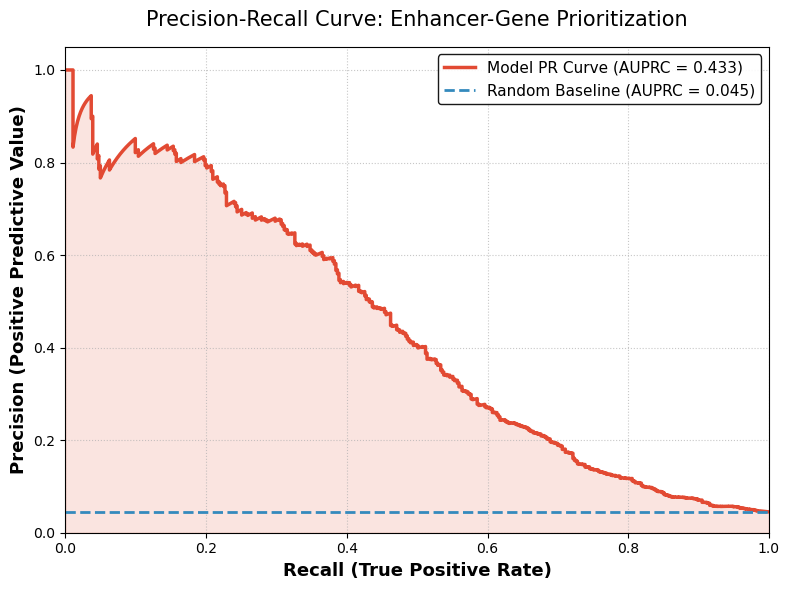

In [9]:
#
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

AUPR: 0.4370


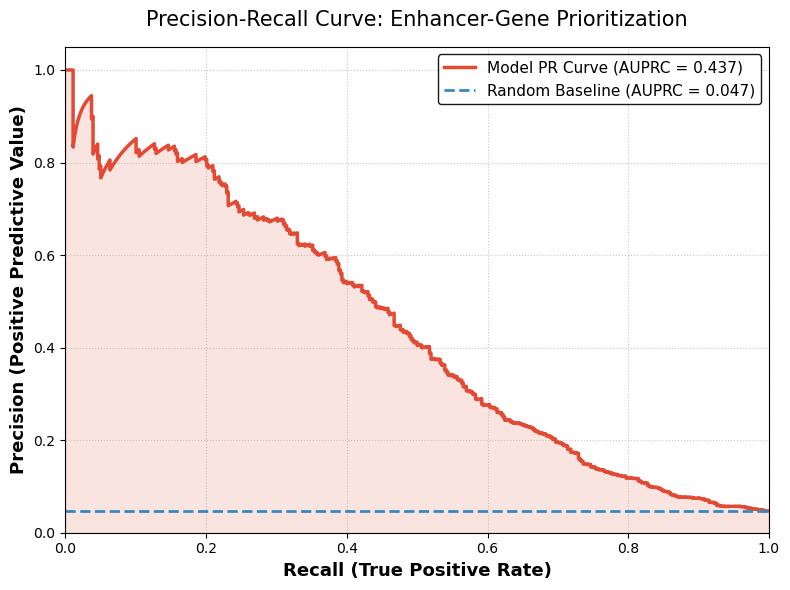

In [10]:
#and only in context now
#and do it in context only
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

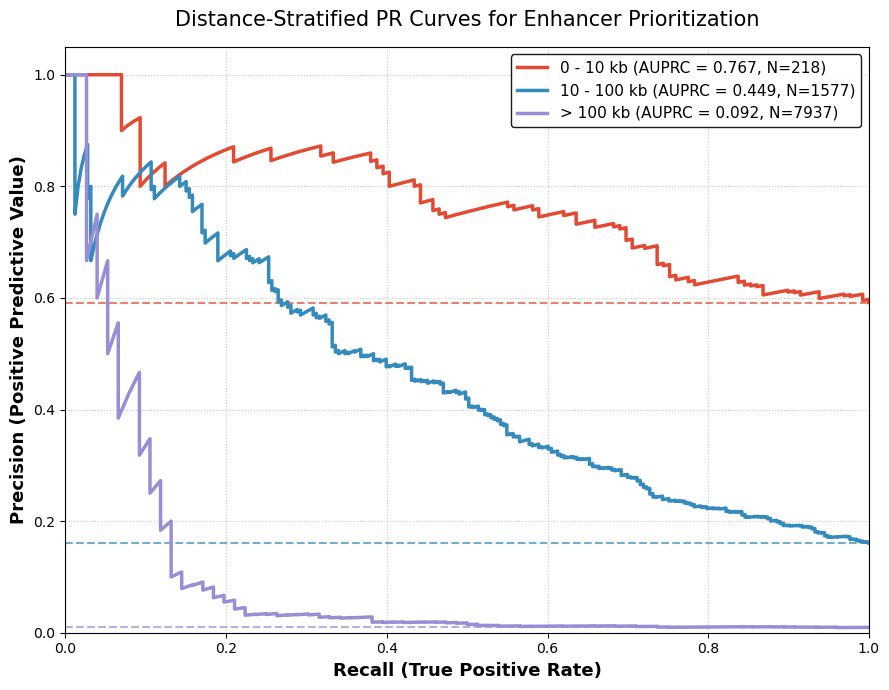

In [13]:
#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

In [14]:
#now let's do transformers
import numpy as np
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_transformer_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_transformer_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

(10280, 4, 32768) (10280,)


In [15]:
from tqdm import tqdm

pool_size = 32
output_length = 32768

score_vector = np.zeros(len(gs_df))
mask_len_maintss = 3*4
mask_len_alttss = 0*4
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    strand = tss_dict[ensgid]['strand']

    # 1. Main TSS is ALWAYS dead center now
    gene_location = output_length // 2

    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(output_length, gene_location + mask_len_maintss + 1)

    mask = np.zeros(output_length)
    mask[startmask:endmask] = 1

    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss

    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(output_length // 2 + alt // pool_size)

            # Alt TSSs can still fall outside the output window
            if alt_location < 0 or alt_location >= output_length:
                continue

            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(output_length, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1

    # 3. Apply the mask to the vector
    tempout = outputs[i] # 4x6144
    if strand == '+':
        og_idx = 0
        alt_idx = 2
    else:
        og_idx = 1
        alt_idx = 3
    original_sum = (tempout[og_idx] * mask).sum()
    altered_sum = (tempout[alt_idx] * mask).sum()

    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:01<00:00, 7147.64it/s]


AUPR: 0.2989


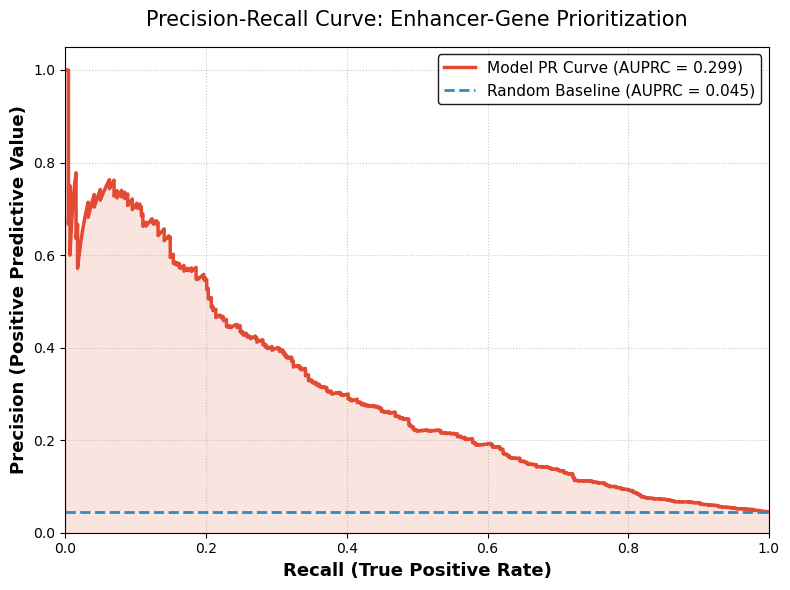

In [16]:
#
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

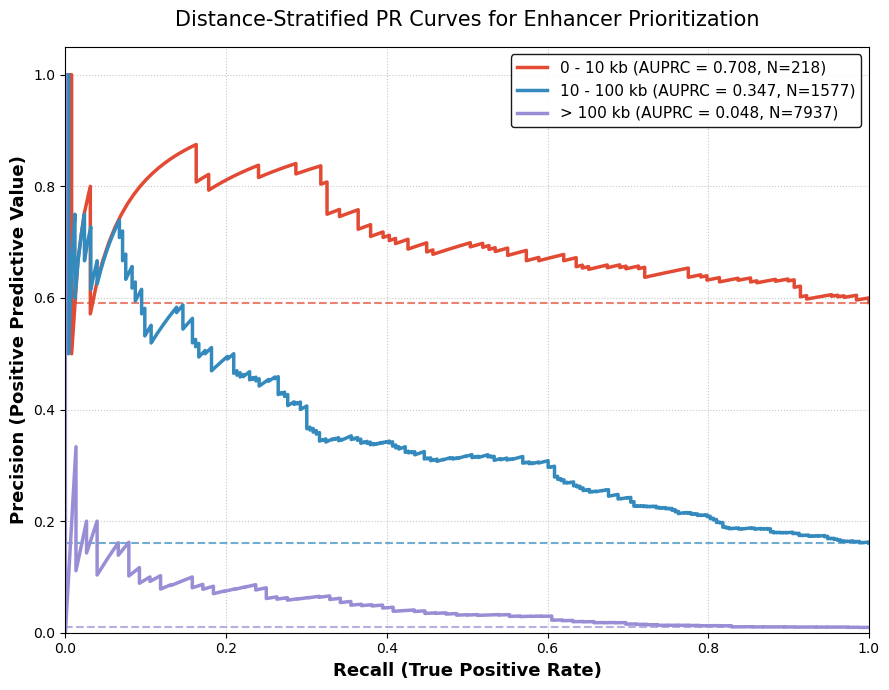

In [17]:
#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

In [18]:
#ok the results actually reasonably promising. I think transformer is undertrained, and we know for sure that striped has some issues. Can honestly continue training it and see what happens?
#not as good on eqtl interestingly lol. 

#let's do some more analysis for the striped model, taking into account the alt TSS and things like that

import numpy as np
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_striped_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_striped_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

from tqdm import tqdm

pool_size = 32
output_length = 32768

score_vector = np.zeros(len(gs_df))
mask_len_maintss = 3*2
mask_len_alttss = 1*4
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    strand = tss_dict[ensgid]['strand']

    # 1. Main TSS is ALWAYS dead center now
    gene_location = output_length // 2

    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(output_length, gene_location + mask_len_maintss + 1)

    mask = np.zeros(output_length)
    mask[startmask:endmask] = 1

    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss

    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(output_length // 2 + alt // pool_size)

            # Alt TSSs can still fall outside the output window
            if alt_location < 0 or alt_location >= output_length:
                continue

            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(output_length, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1

    # 3. Apply the mask to the vector
    tempout = outputs[i] # 4x6144
    if strand == '+':
        og_idx = 0
        alt_idx = 2
    else:
        og_idx = 1
        alt_idx = 3
    original_sum = (tempout[og_idx] * mask).sum()
    altered_sum = (tempout[alt_idx] * mask).sum()

    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

(10280, 4, 32768) (10280,)


100%|██████████| 10280/10280 [00:01<00:00, 5599.82it/s]


AUPR: 0.4539


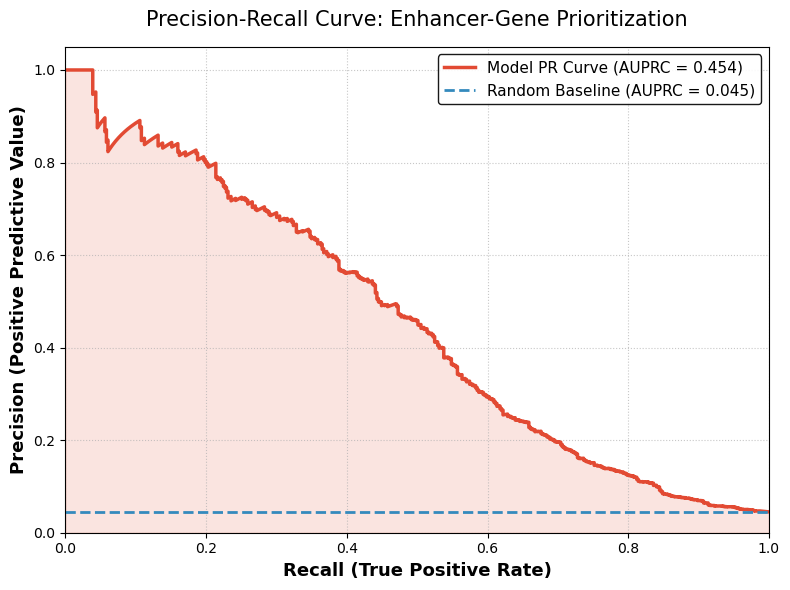

In [20]:
#
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

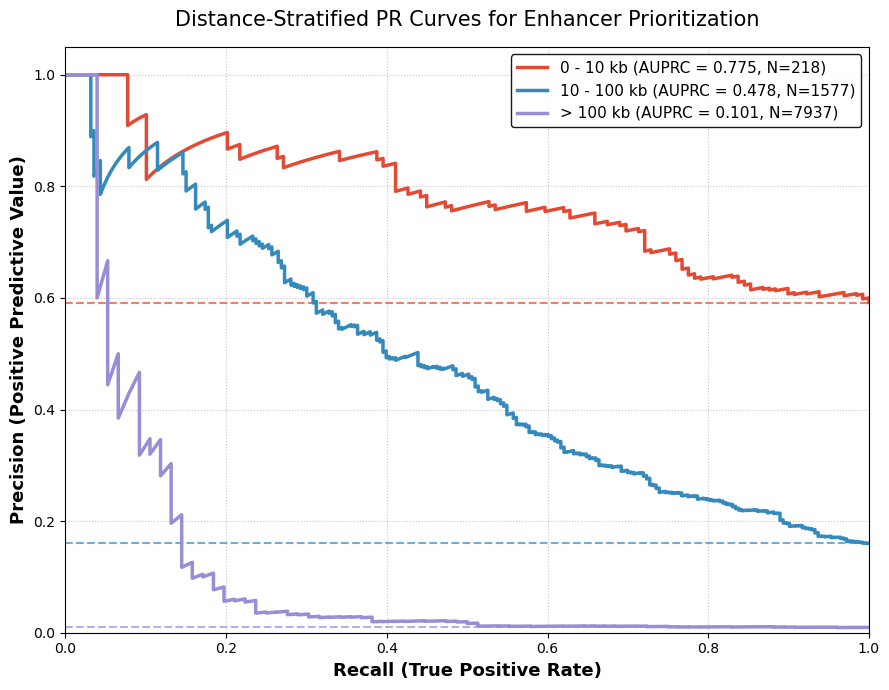

In [21]:
#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

(10280, 4, 32768) (10280,)


100%|██████████| 10280/10280 [00:01<00:00, 5696.95it/s]


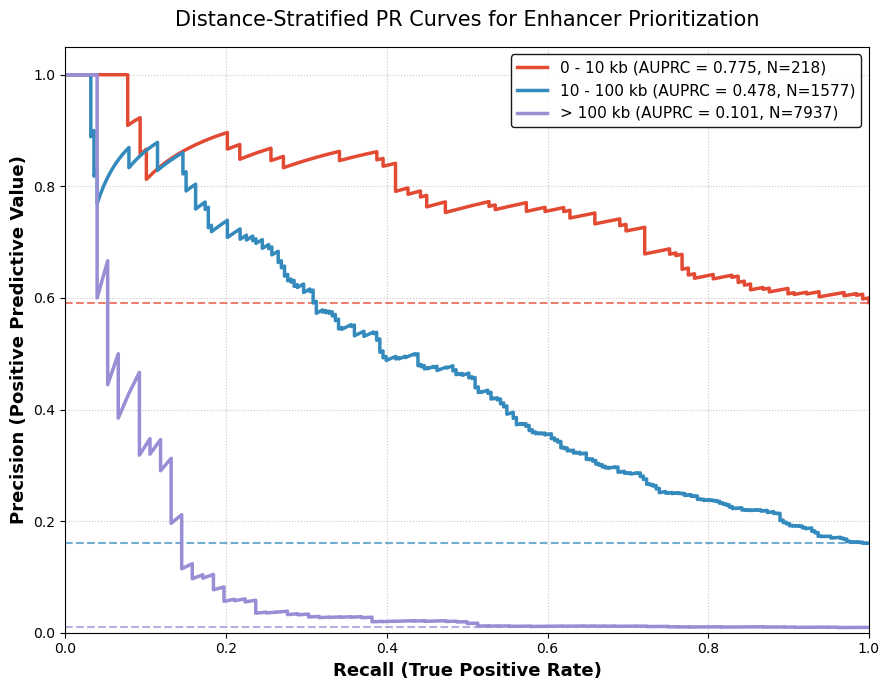

In [9]:
#ok the results actually reasonably promising. I think transformer is undertrained, and we know for sure that striped has some issues. Can honestly continue training it and see what happens?
#not as good on eqtl interestingly lol. 

#let's do some more analysis for the striped model, taking into account the alt TSS and things like that
from sklearn.metrics import precision_recall_curve, auc

import numpy as np
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_striped_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_striped_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

from tqdm import tqdm

pool_size = 32
output_length = 32768

score_vector = np.zeros(len(gs_df))
mask_len_maintss = 1*4
mask_len_alttss = 1*4
pseudo_count = 1e-2

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    # Optional but highly recommended: Skip if the enhancer was outside the input crop
    if not in_context[i]:
        score_vector[i] = 0
        continue

    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    strand = tss_dict[ensgid]['strand']

    # 1. Main TSS is ALWAYS dead center now
    gene_location = output_length // 2

    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(output_length, gene_location + mask_len_maintss + 1)

    mask = np.zeros(output_length)
    mask[startmask:endmask] = 1

    # 2. Alt TSS locations are just their distance from the main TSS center
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss

    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = int(output_length // 2 + alt // pool_size)

            # Alt TSSs can still fall outside the output window
            if alt_location < 0 or alt_location >= output_length:
                continue

            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(output_length, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1

    # 3. Apply the mask to the vector
    tempout = outputs[i] # 4x6144
    if strand == '+':
        og_idx = 0
        alt_idx = 2
    else:
        og_idx = 1
        alt_idx = 3
    original_sum = (tempout[og_idx] * mask).sum()
    altered_sum = (tempout[alt_idx] * mask).sum()

    score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

#now filter to just in context
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[in_context]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[in_context]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
temp_distances = distances[in_context]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", temp_distances <= 10000),
    ("10 - 100 kb", (temp_distances > 10000) & (temp_distances <= 100000)),
    ("> 100 kb", temp_distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

AUPR: 0.4534


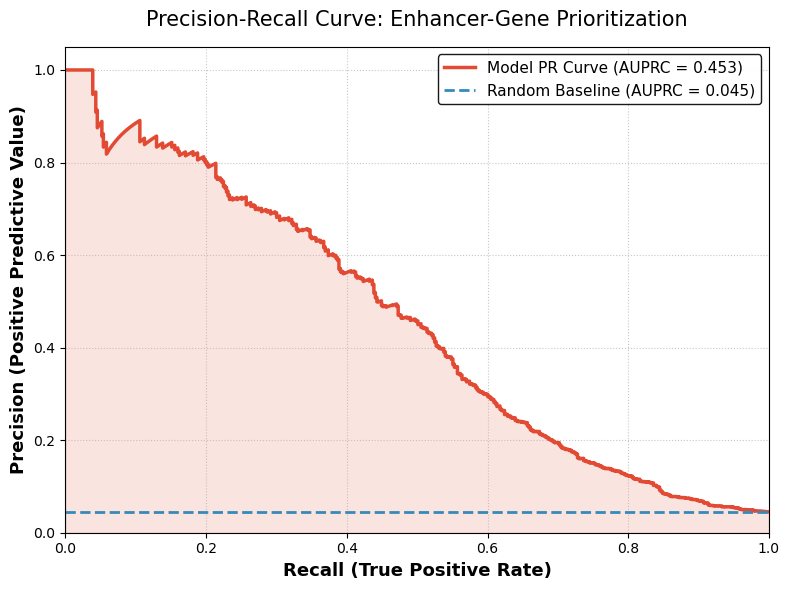

In [10]:
#and now the overall
#
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

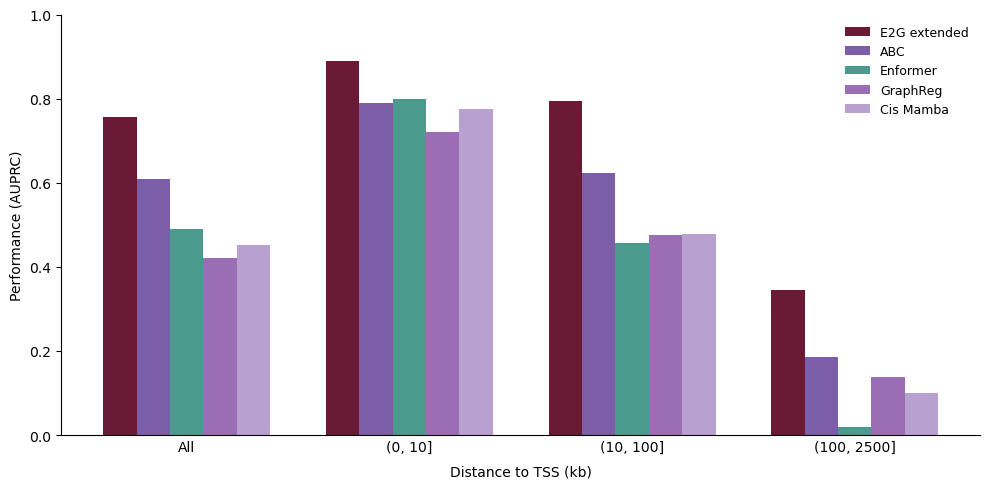

In [12]:
#now let's go ahead and remake the plot!

values_dict = {
    "E2G extended": [0.756, 0.89, 0.795, 0.346],
    # "E2G": [0.635, 0.818, 0.627, 0.175],
    "ABC": [0.61, 0.79, 0.622, 0.186],
    "Enformer": [0.49, 0.80, 0.456, 0.02],
    "GraphReg": [0.42, 0.72, 0.475, 0.139],
    "Cis Mamba": [0.453, 0.775, 0.478, 0.101]
}


import matplotlib.pyplot as plt
import numpy as np

categories = ["All", "(0, 10]", "(10, 100]", "(100, 2500]"]
methods = list(values_dict.keys())
colors = ["#6B1A35", "#7B5EA7", "#4A9B8E", "#9B6DB5", "#B8A0D0", "#6BAED6"]

n_categories = len(categories)
n_methods = len(methods)
bar_width = 0.12
group_spacing = 0.2
x = np.arange(n_categories) * (n_methods * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(10, 5))

for i, (method, color) in enumerate(zip(methods, colors)):
    offsets = x + i * bar_width
    ax.bar(offsets, values_dict[method], width=bar_width, label=method, color=color)

group_centers = x + (n_methods - 1) * bar_width / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(categories)
ax.set_xlabel("Distance to TSS (kb)", labelpad=8)
ax.set_ylabel("Performance (AUPRC)")
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", length=0)

plt.tight_layout()
plt.savefig("crispr_performance.png", dpi=150, bbox_inches="tight")
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

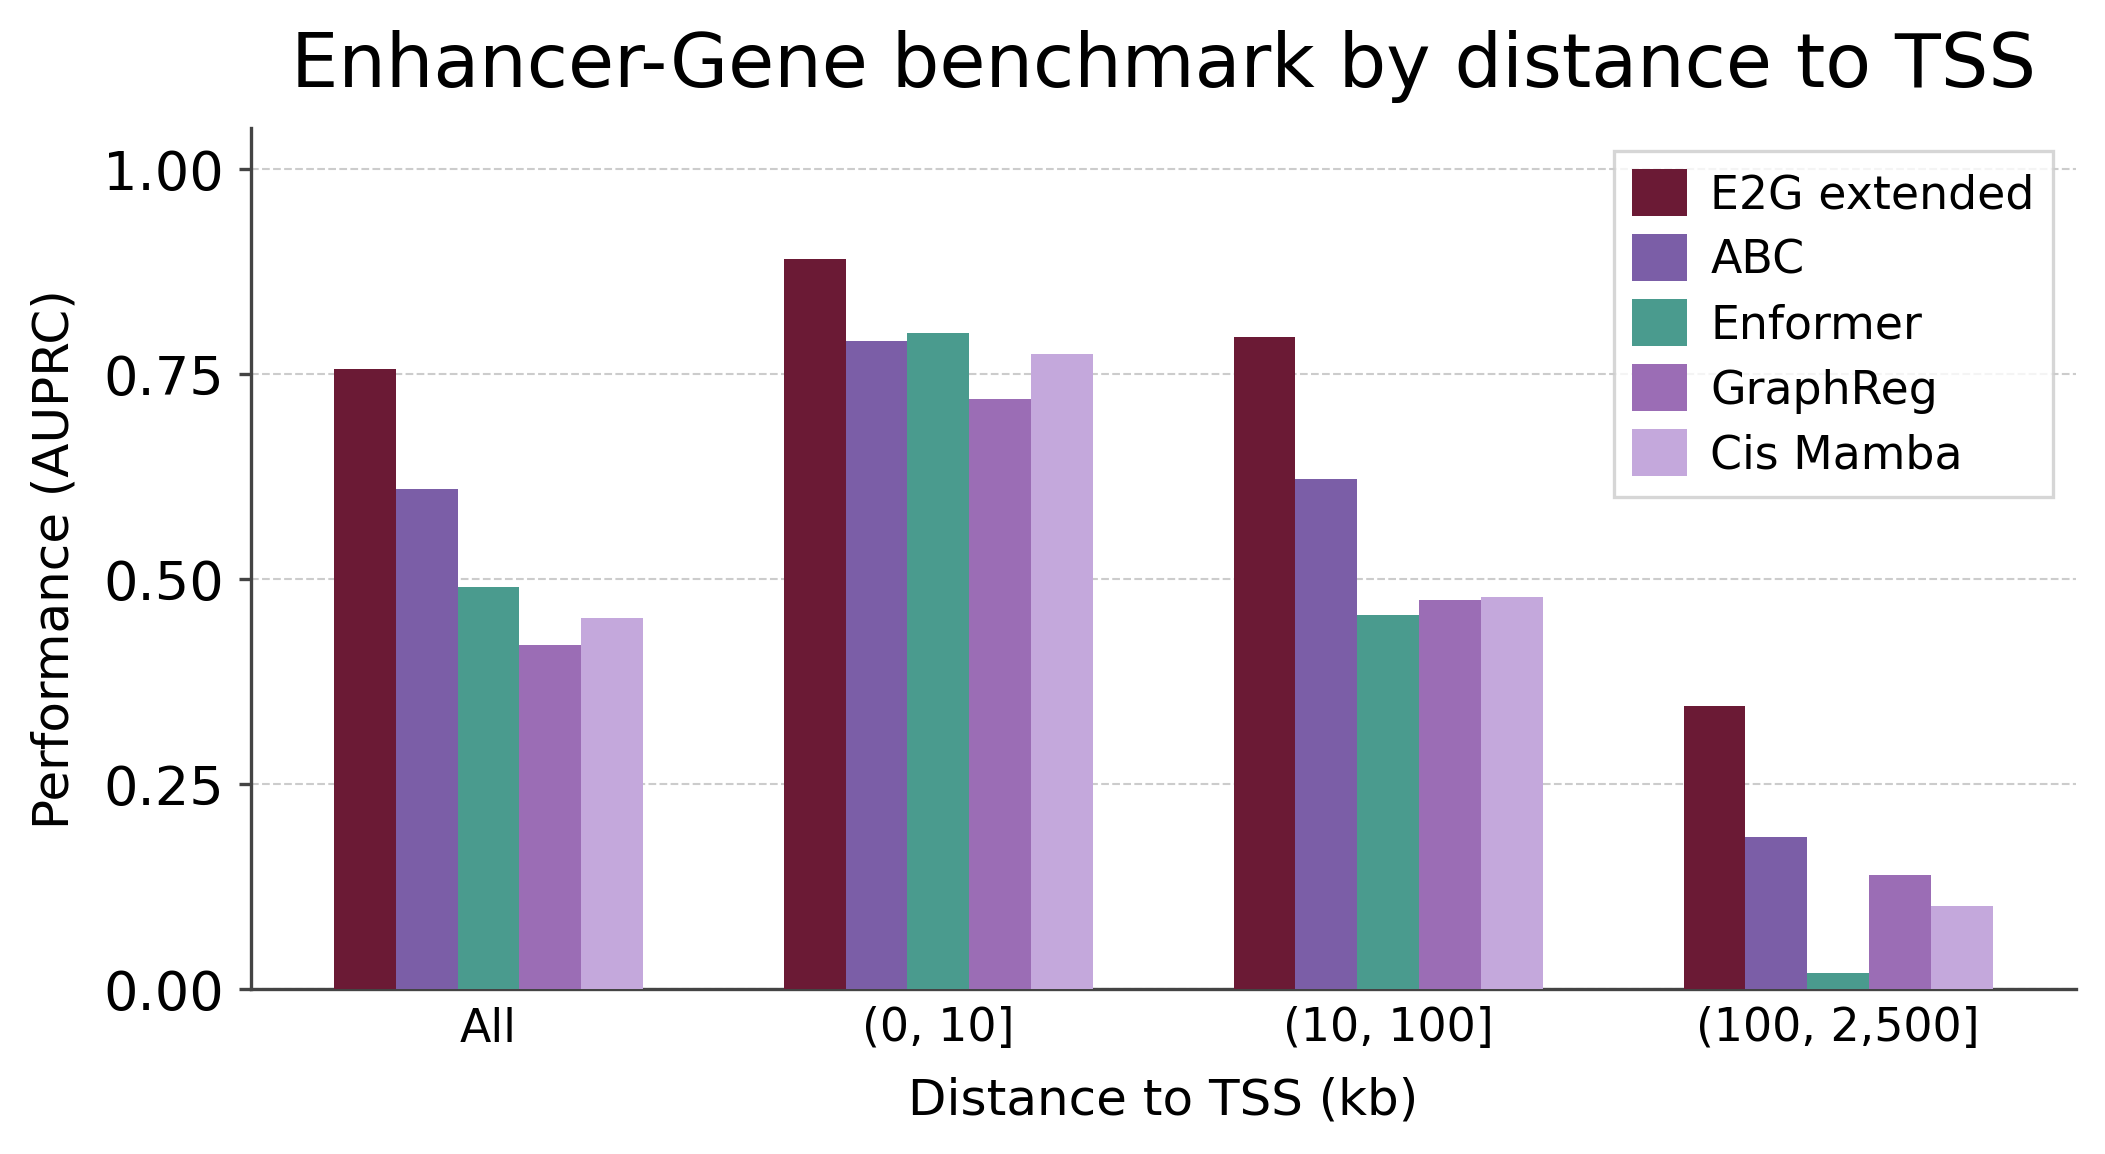

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

values_dict = {
    "E2G extended": [0.756, 0.89, 0.795, 0.346],
    # "E2G":          [0.635, 0.818, 0.627, 0.175],
    "ABC":          [0.610, 0.790, 0.622, 0.186],
    "Enformer":     [0.490, 0.800, 0.456, 0.020],
    "GraphReg":     [0.420, 0.720, 0.475, 0.139],
    "Cis Mamba":    [0.453, 0.775, 0.478, 0.101],
}

categories = ["All", "(0, 10]", "(10, 100]", "(100, 2,500]"]
methods = list(values_dict.keys())
colors = ["#6B1A35", "#7B5EA7", "#4A9B8E", "#9B6DB5", "#C4A8DC", "#6BAED6"]

n_categories = len(categories)
n_methods = len(methods)
bar_width = 0.11
group_spacing = 0.25
x = np.arange(n_categories) * (n_methods * bar_width + group_spacing)

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 300,
})

fig, ax = plt.subplots(figsize=(7, 3.5))

for i, (method, color) in enumerate(zip(methods, colors)):
    offsets = x + i * bar_width
    ax.bar(offsets, values_dict[method], width=bar_width, label=method,
           color=color, linewidth=0, zorder=3)

group_centers = x + (n_methods - 1) * bar_width / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(categories, fontsize=11)
ax.set_xlabel("Distance to TSS (kb)", labelpad=6, fontsize=12)
ax.set_ylabel("Performance (AUPRC)", labelpad=6, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#CCCCCC", zorder=0)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")
ax.tick_params(axis="x", length=0, pad=4)
ax.tick_params(axis="y", length=3, width=0.8, color="#444444")

leg = ax.legend(
    frameon=True,
    fontsize=11,
    ncol=1,
    loc="upper right",
    handlelength=1.2,
    handleheight=1.2,
    handletextpad=0.5,
    labelspacing=0.35,
    bbox_to_anchor=(1.0, 1.0),
    edgecolor="#CCCCCC",
    fancybox=False,
)
leg.get_frame().set_linewidth(0.8)


plt.tight_layout(pad=0.5)
plt.title("Enhancer-Gene benchmark by distance to TSS", fontsize=18, pad=10)
# plt.savefig("crispr_performance.pdf", bbox_inches="tight")
# plt.savefig("crispr_performance.png", dpi=300, bbox_inches="tight")
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

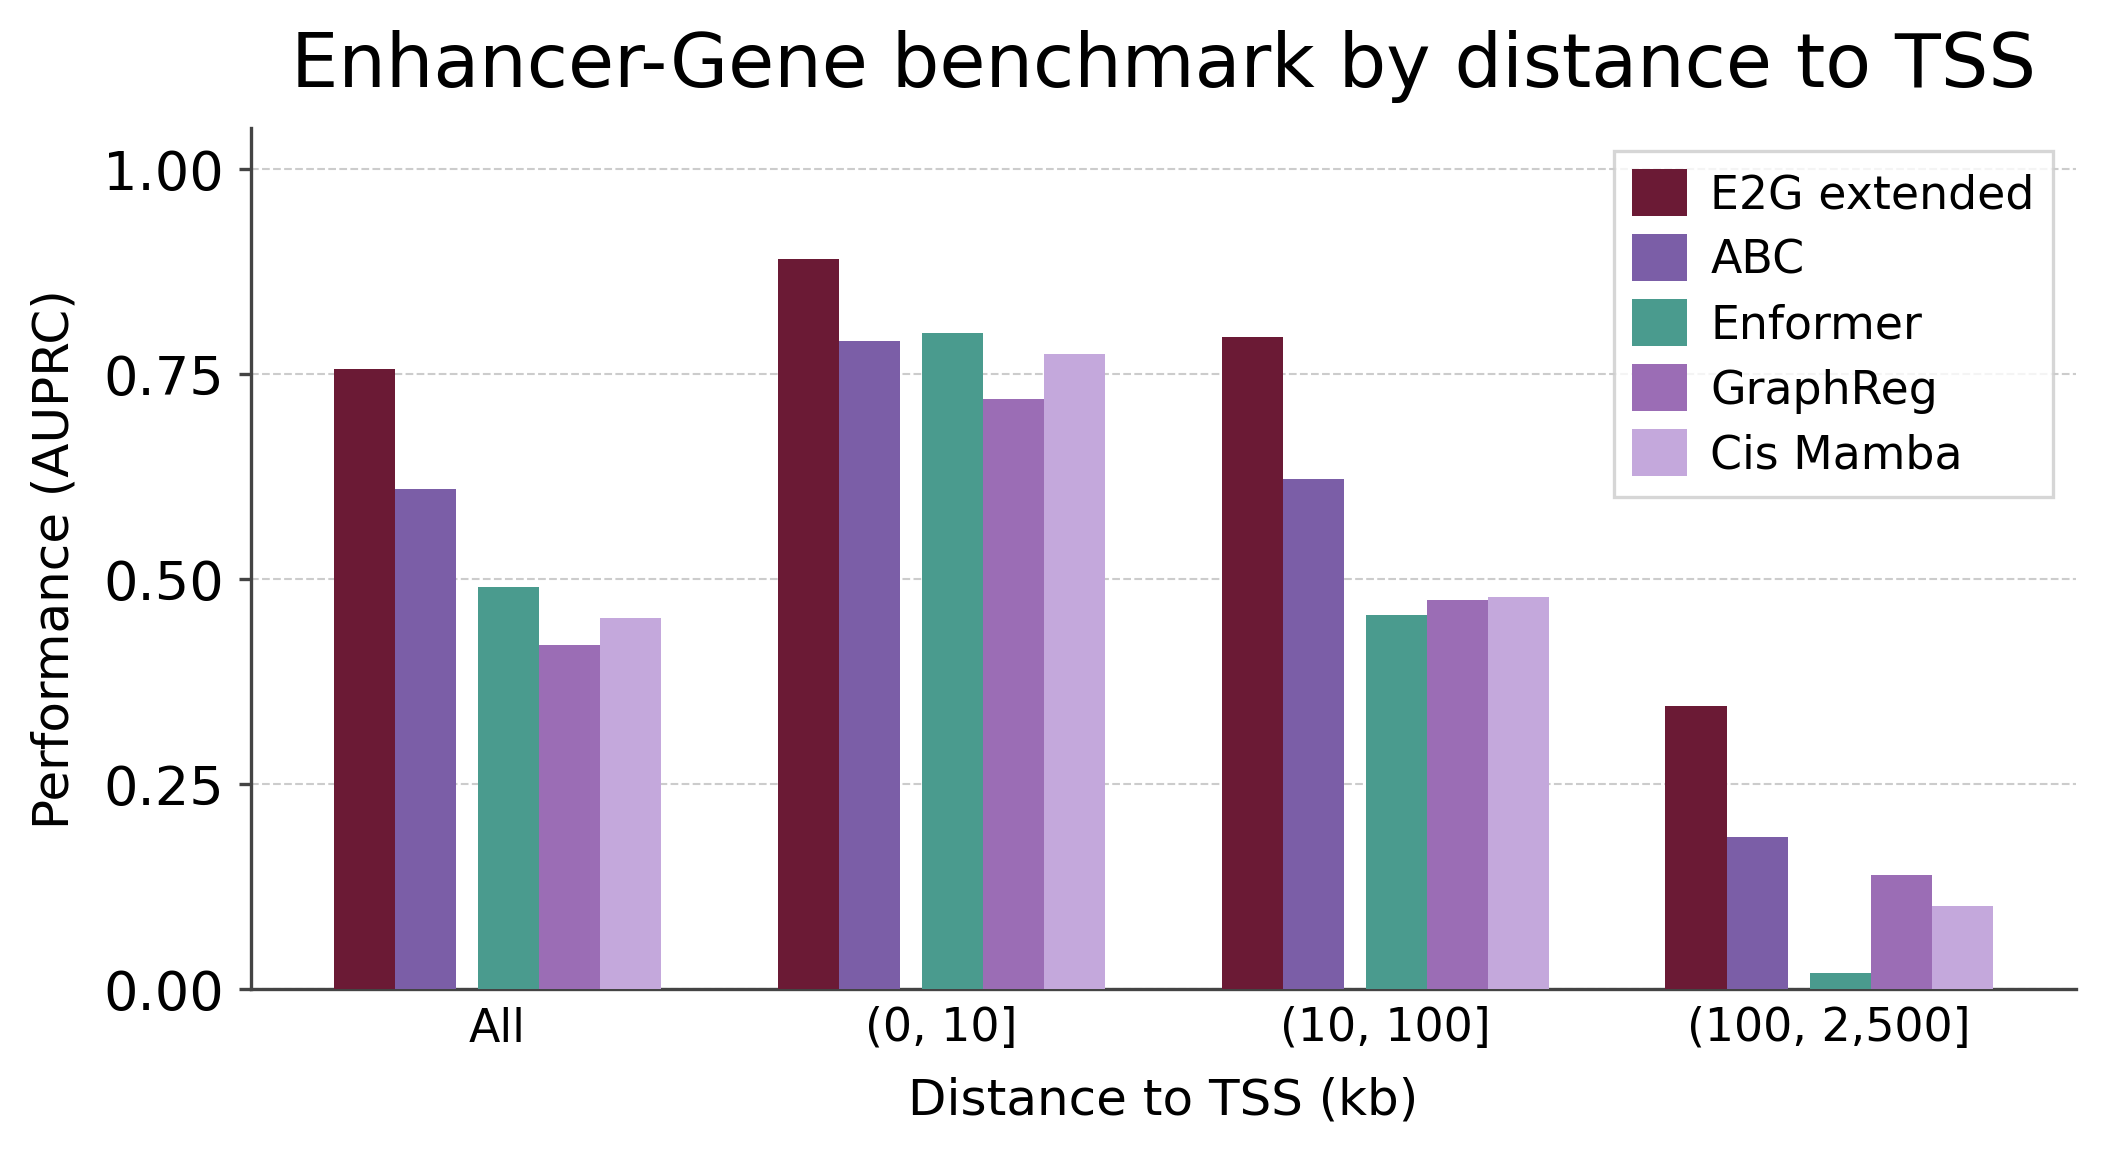

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

values_dict = {
    "E2G extended": [0.756, 0.89, 0.795, 0.346],
    # "E2G":          [0.635, 0.818, 0.627, 0.175],
    "ABC":          [0.610, 0.790, 0.622, 0.186],
    "Enformer":     [0.490, 0.800, 0.456, 0.020],
    "GraphReg":     [0.420, 0.720, 0.475, 0.139],
    "Cis Mamba":    [0.453, 0.775, 0.478, 0.101],
}

categories = ["All", "(0, 10]", "(10, 100]", "(100, 2,500]"]
methods = list(values_dict.keys())
colors = ["#6B1A35", "#7B5EA7", "#4A9B8E", "#9B6DB5", "#C4A8DC", "#6BAED6"]

n_categories = len(categories)
n_methods = len(methods)
bar_width = 0.11
group_spacing = 0.25
x = np.arange(n_categories) * (n_methods * bar_width + group_spacing)

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 300,
})

fig, ax = plt.subplots(figsize=(7, 3.5))

gap = 0.04  # spacing between first 2 and the rest

for i, (method, color) in enumerate(zip(methods, colors)):
    extra = gap if i >= 2 else 0
    offsets = x + i * bar_width + extra
    ax.bar(offsets, values_dict[method], width=bar_width, label=method,
           color=color, linewidth=0, zorder=3)

# account for the gap when centering x tick labels
group_centers = x + (n_methods - 1) * bar_width / 2 + gap / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(categories, fontsize=11)
ax.set_xlabel("Distance to TSS (kb)", labelpad=6, fontsize=12)
ax.set_ylabel("Performance (AUPRC)", labelpad=6, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#CCCCCC", zorder=0)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")
ax.tick_params(axis="x", length=0, pad=4)
ax.tick_params(axis="y", length=3, width=0.8, color="#444444")

leg = ax.legend(
    frameon=True,
    fontsize=11,
    ncol=1,
    loc="upper right",
    handlelength=1.2,
    handleheight=1.2,
    handletextpad=0.5,
    labelspacing=0.35,
    bbox_to_anchor=(1.0, 1.0),
    edgecolor="#CCCCCC",
    fancybox=False,
)
leg.get_frame().set_linewidth(0.8)


plt.tight_layout(pad=0.5)
plt.title("Enhancer-Gene benchmark by distance to TSS", fontsize=18, pad=10)
# plt.savefig("crispr_performance.pdf", bbox_inches="tight")
# plt.savefig("crispr_performance.png", dpi=300, bbox_inches="tight")
plt.show()